# 03 · Preprocessing QA 

This notebook is for **assignment presentation** and validates that preprocessing is correct before training.

Checks included:
- merged dataset size and source mix
- extracted label distribution
- extraction quality report (failures)
- schema sanity checks
- sample records for manual review
- split preview (train/valid/test)

In [1]:
import json
from pathlib import Path
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')
ROOT = Path().resolve().parent

MERGED_PATH = ROOT / 'data' / 'raw' / 'conversations_merged.json'
EXTRACTIONS_PATH = ROOT / 'data' / 'processed' / 'extractions.jsonl'
EXTRACTION_REPORT_PATH = ROOT / 'data' / 'processed' / 'extraction_report.json'
TRAINING_TABLE_PATH = ROOT / 'data' / 'processed' / 'training_table.csv'

print('Paths configured')

Paths configured


## 1) Raw merged dataset sanity

In [2]:
with open(MERGED_PATH, encoding='utf-8') as f:
    merged = json.load(f)

print(f'Total merged conversations: {len(merged)}')
src_counts = pd.Series([r.get('source', 'unknown') for r in merged]).value_counts()
display(src_counts.to_frame('count'))

Total merged conversations: 996


,count
multiwoz_2.2,700
unknown,296


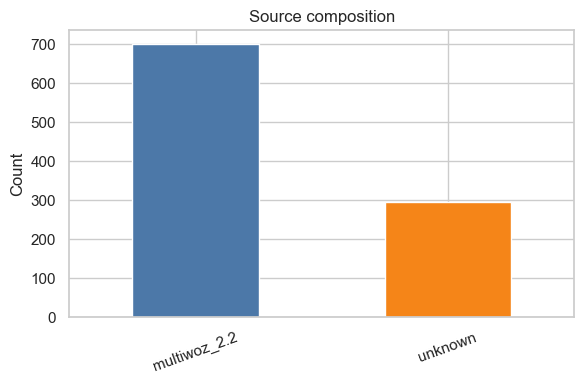

In [3]:
fig, ax = plt.subplots(figsize=(6,4))
src_counts.plot(kind='bar', ax=ax, color=['#4c78a8','#f58518','#54a24b','#e45756'])
ax.set_title('Source composition')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## 2) Extraction report QA

In [4]:
with open(EXTRACTION_REPORT_PATH, encoding='utf-8') as f:
    rep = json.load(f)

stats = rep.get('stats', {})
display(pd.DataFrame([stats]))

total = stats.get('total', 0)
ok = stats.get('ok', 0)
print(f'Extraction success rate: {ok/max(total,1):.2%}')
print('Label counts:', rep.get('label_counts', {}))

,total,from_cache,llm_calls,ok,schema_failures,llm_failures,low_confidence_filtered
0,996,0,996,996,0,0,0


Extraction success rate: 100.00%
Label counts: {'intent': 731, 'value': 832, 'sentiment': 972, 'life_event': 159, 'competitive': 127}


In [5]:
failures = rep.get('failure_examples', [])
if failures:
    fail_df = pd.DataFrame(failures)
    display(fail_df.head(10))
    if 'reason' in fail_df.columns:
        fig, ax = plt.subplots(figsize=(7,4))
        fail_df['reason'].value_counts().plot(kind='bar', ax=ax)
        ax.set_title('Top extraction failure reasons (sample)')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=30)
        plt.tight_layout()
        plt.show()
else:
    print('No failure examples recorded.')

No failure examples recorded.


## 3) Flattened training table QA

In [6]:
df = pd.read_csv(TRAINING_TABLE_PATH)
print(df.shape)
display(df.head(3))

(996, 31)


,conversation_id,guest_text,parser_confidence,feat_intent_detected,feat_intent_confidence,feat_intent_evidence_len_norm,feat_value_detected,feat_value_confidence,feat_value_evidence_len_norm,feat_sentiment_detected,...,feat_parser_confidence,label_intent,label_value,label_sentiment,label_life_event,label_competitive,record_id,source,cache_key,conversation_turns
0,mwz_000000,i need a place to dine in the center thats exp...,0.85,1.0,0.9,0.400000,1.0,0.8,0.279167,1.0,...,0.85,1,1,1,0,0,mwz_000000,multiwoz_2.2,b7c40c4f945b8928565262d2f5a2244d4e4fb4062879c9...,12
1,mwz_000001,"Guten Tag, I am staying overnight in Cambridge...",0.95,1.0,1.0,0.254167,1.0,1.0,0.183333,1.0,...,0.95,1,1,1,0,0,mwz_000001,multiwoz_2.2,27b97ffccd17808127b04d0a4ea1feb37e31599ec4aa3d...,12
2,mwz_000002,Hi there! Can you give me some info on Cityroo...,0.85,1.0,0.9,0.241667,1.0,0.8,0.087500,1.0,...,0.85,1,1,1,0,0,mwz_000002,multiwoz_2.2,c5fead706a31529519d9fe4511dd7c921c355becee7b8e...,14


In [7]:
label_cols = [c for c in df.columns if c.startswith('label_')]
feat_cols = [c for c in df.columns if c.startswith('feat_')]

print('label cols:', label_cols)
print('n_feat_cols:', len(feat_cols))
print('missing guest_text:', int((df['guest_text'].fillna('').str.strip() == '').sum()))

label cols: ['label_intent', 'label_value', 'label_sentiment', 'label_life_event', 'label_competitive']
n_feat_cols: 19
missing guest_text: 0


,positives
label_sentiment,972
label_value,832
label_intent,731
label_life_event,159
label_competitive,127


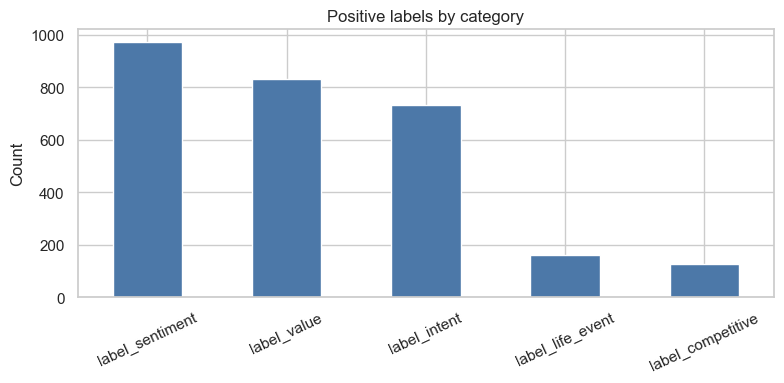

In [8]:
label_counts = df[label_cols].sum().sort_values(ascending=False)
display(label_counts.to_frame('positives'))

fig, ax = plt.subplots(figsize=(8,4))
label_counts.plot(kind='bar', ax=ax, color='#4c78a8')
ax.set_title('Positive labels by category')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

## 4) Manual review samples (important for interview)

In [9]:
random.seed(42)
sample_idx = random.sample(range(len(df)), min(5, len(df)))
for i in sample_idx:
    row = df.iloc[i]
    print('='*80)
    print('record_id:', row.get('record_id', 'n/a'))
    print('labels:', {c: int(row[c]) for c in label_cols})
    print('text:', row['guest_text'][:500])
    print('='*80)

record_id: mwz_000654
labels: {'label_intent': 1, 'label_value': 1, 'label_sentiment': 1, 'label_life_event': 0, 'label_competitive': 0}
text: I am needing help with your train schedules. I will be departing from Birmingham New Street and arriving in Cambridge on Sunday at 18:45. I would like to leave no later than 19:30. I do not care what time it is leaving but check again for it arriving by 18:45. Yes please, and then I need to find a restaurant. I would like a chinese place. The centre please! No thank you that will be all
record_id: mwz_000114
labels: {'label_intent': 1, 'label_value': 1, 'label_sentiment': 1, 'label_life_event': 0, 'label_competitive': 0}
text: I am looking for a restaurant in the centre of town. I am looking for an expensive restaurant in the centre, type of food does not matter but I need a table for 7 people for Tuesday at 13:15. Could we try for Tuesday at 12:15 please. Yes, I'm looking for a particular attraction called Whale of a Time. Could I have the post

## 5) Train/valid/test split preview

In [10]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
valid_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

print('train:', train_df.shape)
print('valid:', valid_df.shape)
print('test :', test_df.shape)

split_summary = pd.DataFrame({
    'train_pos': train_df[label_cols].sum(),
    'valid_pos': valid_df[label_cols].sum(),
    'test_pos': test_df[label_cols].sum(),
})
display(split_summary)

train: (697, 31)
valid: (149, 31)
test : (150, 31)


,train_pos,valid_pos,test_pos
label_intent,513,109,109
label_value,579,129,124
label_sentiment,678,147,147
label_life_event,116,22,21
label_competitive,85,16,26
